### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [14]:
import arxiv as arxiv_lib
from langchain_core.tools import tool

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [15]:
_arxiv_client = arxiv_lib.Client()

@tool
def arxiv(query: str) -> str:
    """Search arxiv.org for academic papers on a topic and return each paper's title, authors, publish date and summary."""
    papers = _arxiv_client.results(arxiv_lib.Search(query=query, max_results=2))
    results = []
    for p in papers:
        results.append(
            f"Published: {p.published.date()}\n"
            f"Title: {p.title}\n"
            f"Authors: {', '.join(a.name for a in p.authors)}\n"
            f"Summary: {p.summary[:500]}"
        )
    return "\n\n".join(results) if results else "No results found."

print(arxiv.name)

arxiv


In [16]:
# Modern arxiv (>=2) is required — its client uses https and avoids the HTTP 301.
# Already added to the project with:  uv add "arxiv>=2"

In [17]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a\n\nPublished: 2025-12-03\nTitle: "All You Need" is Not All You Need for a Paper Title: On the Origins of a Scientific Meme\nAuthors: Anton Alyakin\nSummary: The 2017 paper \'\'Attention Is All You Need\'\' introduced the Transformer architecture-and inadvertently spawned one of machine learning\'s most persistent naming conventions. 

In [18]:
# The wikipedia package's default User-Agent is generic, so Wikimedia rate-limits
# it (HTTP 429 -> the response body is plain text, not JSON -> JSONDecodeError). It
# also defaults to http://. Set a descriptive User-Agent and the https endpoint first.
import wikipedia
wikipedia.wikipedia.USER_AGENT = "LangGraphLearning/1.0 (https://github.com/chiragshah2357/Langgraph)"
wikipedia.wikipedia.API_URL = "https://en.wikipedia.org/w/api.php"

api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [19]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation m'

In [20]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [21]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [22]:
tavily.invoke("Provide me the recent AI news for august 22rd 2026")

[{'title': 'AI Briefing — 22 Aug 2026',
  'url': 'https://www.youtube.com/watch?v=hlZHIPMvJjk',
  'content': "Here is your AI briefing for August 22nd, 2026 with 12 stories. Story one, Nvidia just showed that the harness, not the AI model, is now the real hero. Nvidia says safer AI agent behavior comes from harness level fine-tuning and guard rails, letting even weaker base models stay on task without deep end failures during research evaluations. This approach enables weaker base models to maintain reliability during complex research evaluations. It reduces the necessity for expensive highcapability foundation models to achieve safe autonomous agent behavior. Nvidia sells better guard rails to ensure weaker models don't crash, proving their hardware dependency strategy now includes software safety nets. Story two. The DOJ is investigating a 16Z. What does this mean for venture capital? The DOJ's [...] than 1 million users have clicked the seems like AI slop button via the three dots m

In [23]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily]

In [24]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")

llm_with_tools=llm.bind_tools(tools)

In [25]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the recent AI News". They likely want a summary of recent AI news. Need to fetch latest AI news. Use tavily_search_results_json to search for recent AI news. Then summarize. Possibly also use Wikipedia for background. Let\'s search.', 'tool_calls': [{'id': 'fc_dfa115d1-e5d9-4aa6-ab8c-70e8d74a6422', 'function': {'arguments': '{"query":"latest AI news August 2026"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 257, 'total_tokens': 350, 'completion_time': 0.193477486, 'completion_tokens_details': {'reasoning_tokens': 56}, 'prompt_time': 0.009732094, 'prompt_tokens_details': None, 'queue_time': 0.389854572, 'total_time': 0.20320958}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c868cf1eaa', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'},

In [26]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'latest AI news 2024 August'},
  'id': 'fc_7fa49e1b-9c9e-4bc6-93c9-91d5fa2fdb3a',
  'type': 'tool_call'}]

In [27]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

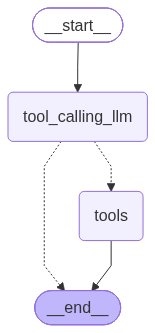

In [31]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (fc_05f9f890-e39f-4892-bc0e-e9cbede149ac)
 Call ID: fc_05f9f890-e39f-4892-bc0e-e9cbede149ac
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2017-06-12
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Ex

In [32]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_8b66274f-b063-4a8d-a941-e5788dfadcae)
 Call ID: fc_8b66274f-b063-4a8d-a941-e5788dfadcae
  Args:
    query: AI news March 3 2025
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "March 2025: All AI updates from the past month - SD Times", "url": "https://sdtimes.com/ai/march-2025-all-ai-updates-from-the-past-month", "content": "Skip to content\n\nSD Times\n\nSD Times\n\nLatest News\n\n# March 2025: All AI updates from the past month\n\nByJenna Barron\n\nSoftware companies are constantly trying to add more and more AI features to their platforms, and AI companies are constantly releasing new models and features. \n\nHere are all the major AI updates we 

In [33]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================

**Machine learning (ML)** is a sub‑field of artificial intelligence (AI) that focuses on developing algorithms and statistical models that enable computers to *learn* from data, identify patterns, and make decisions or predictions without being explicitly programmed for each specific task.

---

## Core Idea

1. **Data → Model → Prediction**  
   - **Data**: A collection of examples (e.g., images, text, sensor readings).  
   - **Model**: A mathematical representation (e.g., a neural network, decision tree, linear regression) whose parameters are tuned during training.  
   - **Prediction/Inference**: Once trained, the model can produce outputs (class labels, numeric values, actions) for new, unseen inputs.

2. **Learning Process**  
   - **Training**: The model’s parameters are adjusted to minimize 